# Comparativo según los parámetros físicos

**Experimento de apoyo. No forma parte del anexo de código del TFM.**

Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019). Carlos J. Bravo I.

La Configuración 1 identifica el exponente y el coeficiente de la ley de crecimiento a partir de las
curvas medidas, en lugar de tomarlos de la literatura. Este cuaderno mide qué cuesta esa decisión:
reconstruye la configuración completa con cada procedencia posible de esos dos parámetros, cambiando
únicamente el exponente y el coeficiente, y la evalúa espécimen por espécimen.

La cuestión que responde no es cuál de las procedencias puntúa mejor en una probeta concreta, sino
cuál se comporta bien en todas. Una procedencia que gane en un espécimen y se hunda en el resto no
es preferible, y el reparto por espécimen es lo único que permite distinguir un caso del otro.

El cálculo completo entrena treinta y siete conjuntos de modelos y tarda alrededor de media hora,
de modo que sus penalizaciones quedan registradas en `results/penalizaciones.json` y el cuaderno las
reutiliza al reejecutarse. Para rehacerlo desde cero basta con poner `RECALCULAR` a `True` en la
primera celda de código, o con borrar ese fichero.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | Las procedencias contrastadas |
| 2 | El protocolo de evaluación por espécimen |
| 3 | Penalización por espécimen y procedencia |
| 4 | El coeficiente que minimiza la penalización de T8 |
| 5 | Las curvas entregadas, espécimen por espécimen |
| 6 | La procedencia frente a la configuración |
| 7 | Frente a las referencias del certamen |
| 8 | Los pesos entrenados |
| 9 | Conclusiones |

In [1]:
import json, math, sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
RAIZ = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "config1_cnn_pinn" / "model.py").is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

torch.set_num_threads(4)
pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

from config1_cnn_pinn.data import build_specimen_batches, load_labels
from config1_cnn_pinn.evaluate import ABLATION, BASE, build_submission
from config1_cnn_pinn.train import evaluate_ensemble
from config1_cnn_pinn.hyperparameter_sources import M_FAA, LOG_C_FAA
from config1_cnn_pinn.physics import pooled_log_c
from physics_calibration.objectives import phm_penalty
from physics_calibration.data import load_curve
from src.pesos_entrenados import cargar_o_entrenar, inventario
from config1_cnn_pinn.train import Config, LOSO_FOLDS, TRAIN_POOL, train_ensemble

MARCA_DE_AGUA = "Carlos J. Bravo (2026)"


def marca_de_agua(fig, texto=MARCA_DE_AGUA):
    fig.text(0.995, 0.004, texto, fontsize=8, color="0.45", alpha=0.38,
             ha="right", va="bottom", fontweight="bold")
    return fig


RESULTADOS = RAIZ / "comparativo_parametros" / "results"
RESULTADOS.mkdir(parents=True, exist_ok=True)
REGISTRO = RESULTADOS / "penalizaciones.json"

RECALCULAR = False
ENTRENAR_DE_NUEVO = False

N_SEMILLAS_PLIEGUE = 3
N_SEMILLAS_CERTAMEN = 5
ANCLAS = 2
COTA = float(Config(**BASE).cota_entrega_mm)
ESPECIMENES = list(LOSO_FOLDS) + ["T7", "T8"]
INICIO = time.perf_counter()
print(f"Pliegues de entrenamiento: {', '.join(LOSO_FOLDS)}")
print(f"Probetas de validación   : T7, T8")
print(f"Anclas concedidas        : {ANCLAS}")

Pliegues de entrenamiento: T1, T3, T4, T6
Probetas de validación   : T7, T8
Anclas concedidas        : 2


## 1. Las procedencias contrastadas

Se comparan siete orígenes para el par formado por el exponente y el coeficiente. Dos proceden de la
identificación realizada en este trabajo, cuatro de la literatura y uno es el valor que minimiza la
penalización de T8, incluido como referencia superior y no como candidato, por razones que el
apartado 4 desarrolla.

El coeficiente de la procedencia propia no se fija aquí: se reidentifica sobre los
especímenes de entrenamiento al exponente correspondiente, porque exponente y coeficiente se
desplazan conjuntamente y fijar uno sin el otro produce un par incoherente.

In [2]:
PROCEDENCIAS = {
    "Identificada en este trabajo, m = 2.00": {"m": 2.00, "log_c": None, "clave": "identificada",
        "origen": "Identificación propia, solución cerrada no singular"},
    "Coeficiente que minimiza T8": {"m": 2.00, "log_c": -9.135, "clave": "optimo_t8",
        "origen": "Referencia superior, no es un candidato"},
    "Dourado y Viana (2019)": {"m": 3.859, "log_c": math.log10(5.008e-10), "clave": "dourado",
        "origen": "Probetas de 2024-T3 en aire, unidades no declaradas"},
    "Yang et al. (2011)": {"m": 3.09, "log_c": math.log10(5.75e-8), "clave": "yang",
        "origen": "2024-T4 en probeta compacta, unidades no declaradas"},
    "Forman et al. (2005), base de datos de la FAA": {"m": M_FAA, "log_c": LOG_C_FAA,
        "clave": "forman",
        "origen": "Chapa de 2024-T3, Walker en unidades imperiales convertido"},
    "Ventana genérica para metales": {"m": 3.0, "log_c": -12.0, "clave": "generica",
        "origen": "Intervalo publicado para metales, no específico de la aleación"},
}
ADOPTADA = "Identificada en este trabajo, m = 2.00"

etiquetas = load_labels()
filas = []
for nombre, spec in PROCEDENCIAS.items():
    spec["log_c_efectivo"] = (float(pooled_log_c(spec["m"])) if spec["log_c"] is None
                              else spec["log_c"])
    filas.append({"procedencia": nombre, "m": round(spec["m"], 3),
                  "log10 C": round(spec["log_c_efectivo"], 3),
                  "C": f"{10 ** spec['log_c_efectivo']:.3e}", "origen": spec["origen"]})
display(pd.DataFrame(filas))

,procedencia,m,log10 C,C,origen
0,"Identificada en este trabajo, m = 2.00",2.000,-8.426,3.746e-09,"Identificación propia, solución cerrada no sin..."
1,Coeficiente que minimiza T8,2.000,-9.135,7.328e-10,"Referencia superior, no es un candidato"
2,Dourado y Viana (2019),3.859,-9.300,5.008e-10,"Probetas de 2024-T3 en aire, unidades no decla..."
3,Yang et al. (2011),3.090,-7.240,5.750e-08,"2024-T4 en probeta compacta, unidades no decla..."
4,"Forman et al. (2005), base de datos de la FAA",3.273,-10.480,3.312e-11,"Chapa de 2024-T3, Walker en unidades imperiale..."
5,Ventana genérica para metales,3.000,-12.000,1.000e-12,"Intervalo publicado para metales, no específic..."


## 2. El protocolo de evaluación por espécimen

Cada procedencia se evalúa sobre seis especímenes con un mismo criterio: la red dispone de dos
medidas de grieta no nula y debe entregar el resto de la curva por extrapolación, que es exactamente
el presupuesto de información que el certamen concede en validación.

Los cuatro especímenes de entrenamiento se evalúan dejando uno fuera cada vez, de modo que el
estimador nunca ve la probeta que puntúa. Las dos de validación se evalúan con el protocolo del
certamen, entrenando sobre el conjunto completo de entrenamiento.

T2 y T5 quedan fuera de la comparación, y el motivo es estructural. Ambos tienen solo dos medidas de
grieta no nula en todo su registro, de manera que al concederles las dos anclas del protocolo no
queda ningún punto por predecir y la penalización no está definida. Es la misma razón por la que no
figuran entre los pliegues de la validación cruzada.

In [3]:
def resumir(entrega, observado=None):
    d = {"penalizacion": entrega["penalizacion"],
         "ciclos": list(entrega["cycles"]),
         "entregada_mm": list(entrega["pred_mm"]),
         "medida_mm": list(entrega["true_mm"]),
         "corte": entrega["cutoff_cycle"]}
    if observado is not None:
        ciclos_obs, est_obs = observado
        d["ciclos_obs"] = [float(c) for c in ciclos_obs]
        d["estimado_obs"] = [float(v) for v in est_obs]
    return d


def conjunto(nombre, cfg, lotes, entrena, n_semillas):
    modelos, _, _ = cargar_o_entrenar(
        f"comparativo/{nombre}", cfg,
        lambda: train_ensemble(cfg, lotes, entrena, n_seeds=n_semillas),
        forzar=ENTRENAR_DE_NUEVO, entrenados_sobre=entrena)
    return modelos


def evaluar_procedencia(spec):
    cfg = Config(**{**BASE, "m_exponent": spec["m"], "log_c_prior": spec["log_c_efectivo"]})
    lotes = build_specimen_batches(etiquetas, cfg.m_exponent)
    clave = spec["clave"]
    salida = {}
    for fuera in LOSO_FOLDS:
        entrena = [n for n in TRAIN_POOL if n != fuera and n in lotes]
        modelos = conjunto(f"{clave}_sin_{fuera}", cfg, lotes, entrena, N_SEMILLAS_PLIEGUE)
        salida[fuera] = resumir(build_submission(modelos, lotes, cfg, fuera,
                                                 n_observed=ANCLAS))
    entrena = [n for n in TRAIN_POOL if n in lotes]
    modelos = conjunto(f"{clave}_certamen", cfg, lotes, entrena, N_SEMILLAS_CERTAMEN)
    for val in ("T7", "T8"):
        ciclos_obs, est_obs, _, _ = evaluate_ensemble(modelos, lotes[val], cfg)
        salida[val] = resumir(build_submission(modelos, lotes, cfg, val),
                              observado=(ciclos_obs, est_obs))
    return salida


def evaluar_arquitecturas():
    salida = {}
    variantes = (("Configuraciones 1, 2 y 2b", "media",
                  ABLATION["Configuración 1 (1D-CNN + PINN)"]),
                 ("Configuraciones 3, 4 y 4b", "ponderado",
                  {**ABLATION["Configuración 1 (1D-CNN + PINN)"],
                   "architecture": "cnn_attention_pinn"}))
    for etq, clave, ajustes in variantes:
        cfg = Config(**ajustes)
        lotes = build_specimen_batches(etiquetas, cfg.m_exponent)
        nombres = [n for n in TRAIN_POOL if n in lotes]
        modelos = conjunto(f"arquitectura_{clave}", cfg, lotes, nombres, N_SEMILLAS_CERTAMEN)
        salida[etq] = {s: build_submission(modelos, lotes, cfg, s)["penalizacion"]
                       for s in ("T7", "T8")}
    return salida


registrado = None
if REGISTRO.exists() and not RECALCULAR:
    candidato = json.loads(REGISTRO.read_text())
    guardadas = candidato.get("procedencias", {})
    def utilizable(bloque):
        return (isinstance(bloque.get("T8"), dict)
                and "entregada_mm" in bloque["T8"]
                and all("ciclos_obs" in bloque[v] for v in ("T7", "T8")))

    completo = (set(PROCEDENCIAS) <= set(guardadas)
                and "arquitecturas" in candidato
                and all(utilizable(guardadas[n]) for n in PROCEDENCIAS))
    if completo:
        registrado = {"procedencias": {n: guardadas[n] for n in PROCEDENCIAS},
                      "arquitecturas": candidato["arquitecturas"]}

if registrado is not None:
    detalle = registrado["procedencias"]
    arquitecturas = registrado["arquitecturas"]
    print(f"Se leen las penalizaciones registradas en {REGISTRO.name}.")
    print("Para rehacer el cálculo, poner RECALCULAR a True o borrar ese fichero.")
else:
    detalle = {}
    for nombre, spec in PROCEDENCIAS.items():
        t0 = time.perf_counter()
        detalle[nombre] = evaluar_procedencia(spec)
        print(f"{nombre:46s} {time.perf_counter() - t0:5.0f} s", flush=True)
    arquitecturas = evaluar_arquitecturas()
    REGISTRO.write_text(json.dumps({"procedencias": detalle,
                                    "arquitecturas": arquitecturas},
                                   indent=1, ensure_ascii=False))
    print(f"\nRegistrado en {REGISTRO}")
print(f"Tiempo acumulado: {(time.perf_counter() - INICIO) / 60:.1f} min")

Se leen las penalizaciones registradas en penalizaciones.json.
Para rehacer el cálculo, poner RECALCULAR a True o borrar ese fichero.
Tiempo acumulado: 0.0 min


## 3. Penalización por espécimen y procedencia

La tabla recoge la penalización oficial de cada procedencia en cada espécimen. Menor es mejor. Las
cuatro primeras columnas corresponden a especímenes de entrenamiento evaluados dejando uno fuera, y
las dos últimas a las probetas de validación bajo el protocolo del certamen.

In [4]:
filas = []
for nombre, spec in PROCEDENCIAS.items():
    fila = {"procedencia": nombre, "m": round(spec["m"], 3),
            "log10 C": round(spec["log_c_efectivo"], 3)}
    for e in ESPECIMENES:
        fila[e] = round(detalle[nombre][e]["penalizacion"], 2)
    pliegues = [detalle[nombre][e]["penalizacion"] for e in LOSO_FOLDS]
    fila["media en pliegues"] = round(float(np.mean(pliegues)), 2)
    fila["peor pliegue"] = round(float(np.max(pliegues)), 2)
    fila["T7 + T8"] = round(detalle[nombre]["T7"]["penalizacion"] + detalle[nombre]["T8"]["penalizacion"], 2)
    fila["suma de los seis"] = round(sum(detalle[nombre][e]["penalizacion"] for e in ESPECIMENES), 2)
    filas.append(fila)
display(pd.DataFrame(filas))

print("Especímenes en los que cada procedencia obtiene la menor penalización:")
for nombre in PROCEDENCIAS:
    gana = [e for e in ESPECIMENES
            if min(PROCEDENCIAS, key=lambda k: detalle[k][e]["penalizacion"]) == nombre]
    if gana:
        print(f"   {nombre:46s} {len(gana)} de {len(ESPECIMENES)}  ({', '.join(gana)})")

,procedencia,m,log10 C,T1,T3,T4,T6,T7,T8,media en pliegues,peor pliegue,T7 + T8,suma de los seis
0,"Identificada en este trabajo, m = 2.00",2.000,-8.426,20.21,8.16,16.03,10.38,6.49,90.45,13.70,20.21,96.94,151.73
1,Coeficiente que minimiza T8,2.000,-9.135,122.55,214.10,278.13,73.63,186.89,15.73,172.10,278.13,202.62,891.02
2,Dourado y Viana (2019),3.859,-9.300,32.04,26.29,52.01,72.48,31.77,89.85,45.71,72.48,121.61,304.43
3,Yang et al. (2011),3.090,-7.240,31.71,26.08,51.45,72.31,31.69,90.12,45.39,72.31,121.81,303.37
4,"Forman et al. (2005), base de datos de la FAA",3.273,-10.480,141.49,219.51,322.37,82.73,202.06,14.17,191.53,322.37,216.23,982.34
5,Ventana genérica para metales,3.000,-12.000,201.04,318.29,394.22,114.73,289.55,111.28,257.07,394.22,400.83,1429.11


Especímenes en los que cada procedencia obtiene la menor penalización:
   Identificada en este trabajo, m = 2.00         5 de 6  (T1, T3, T4, T6, T7)
   Forman et al. (2005), base de datos de la FAA  1 de 6  (T8)


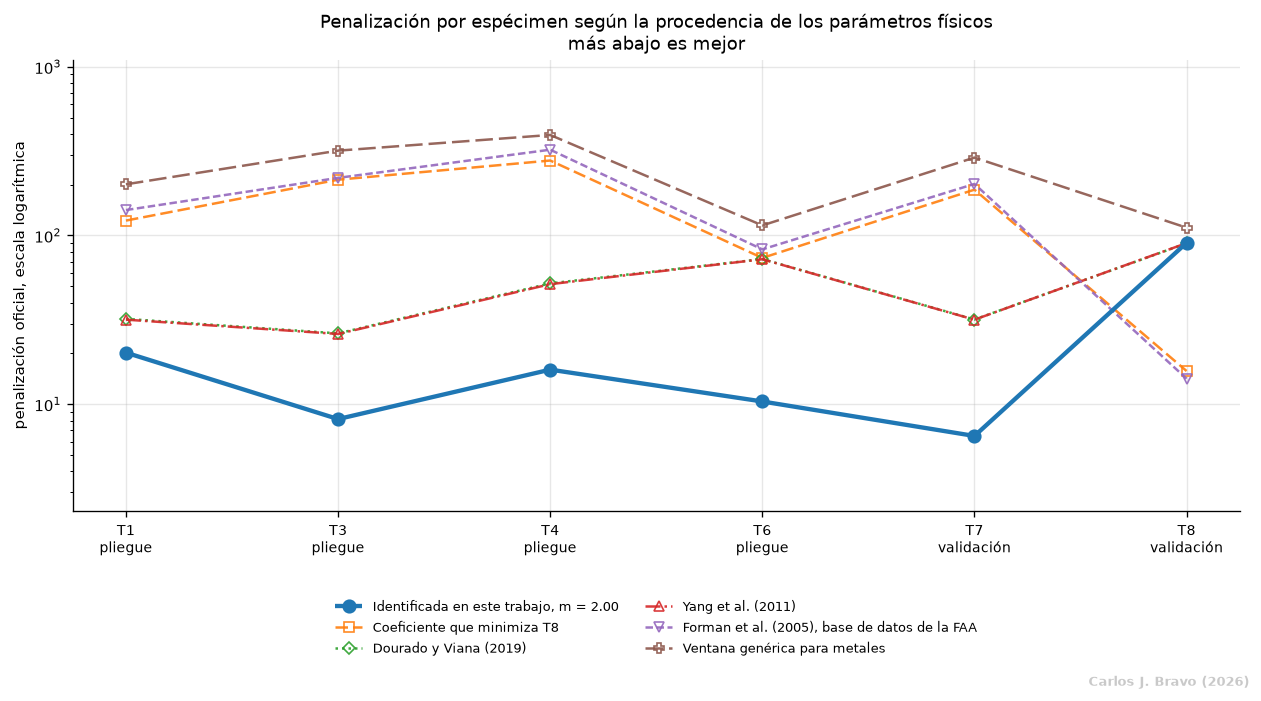

In [5]:
COLORES = plt.cm.tab10(np.linspace(0, 1, 10))
TRAZOS = [(0, ()), (0, (5, 2)), (0, (1, 1.6)), (0, (6, 1.6, 1, 1.6)),
          (0, (3, 1.4)), (0, (7, 2.4))]
MARCAS = ["o", "s", "D", "^", "v", "P"]

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for k, nombre in enumerate(PROCEDENCIAS):
    y = [detalle[nombre][e]["penalizacion"] for e in ESPECIMENES]
    propia = nombre.startswith("Identificada")
    ax.plot(range(len(ESPECIMENES)), y, marker=MARCAS[k], linestyle=TRAZOS[k],
            lw=2.6 if propia else 1.5, ms=7.5 if propia else 5.5,
            color=COLORES[k], alpha=1.0 if propia else .9,
            markerfacecolor="none" if not propia else None,
            label=nombre, zorder=3 if propia else 2)
ax.set_xticks(range(len(ESPECIMENES)))
ax.set_xticklabels([f"{e}\n{'pliegue' if e in LOSO_FOLDS else 'validación'}" for e in ESPECIMENES],
                   fontsize=8.5)
ax.set(yscale="log", ylabel="penalización oficial, escala logarítmica",
       title="Penalización por espécimen según la procedencia de los parámetros físicos\n"
             "más abajo es mejor")
ax.margins(y=.25)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2, frameon=False)
marca_de_agua(fig)
fig.tight_layout(); plt.show()

La figura separa lo que una tabla de totales esconde. Una procedencia que se comporte bien de forma
consistente dibuja una línea baja y plana; una que gane en un espécimen y falle en el resto dibuja
una línea quebrada, y esa distinción es la que decide.

Dos de las curvas discurren casi superpuestas. Dourado y Viana y Yang et al. producen penalizaciones
que difieren en menos de una unidad en los seis especímenes, pese a partir de exponentes y
coeficientes distintos, y se distinguen en la figura por el trazo y no por su posición.

## 4. El coeficiente que minimiza la penalización de T8

La fila correspondiente al coeficiente que minimiza T8 no es un candidato sino una referencia
superior, y conviene ver por qué. Se obtiene barriendo el coeficiente con el estimador congelado y
quedándose con el valor que deja la entrega de T8 más cerca de la curva medida, de modo que emplea
información de la probeta que después puntúa. Lo que mide es el margen que queda en el coeficiente,
no un resultado alcanzable.

In [6]:
filas = []
for nombre in (ADOPTADA, "Coeficiente que minimiza T8",
               "Forman et al. (2005), base de datos de la FAA"):
    fila = {"procedencia": nombre}
    for e in ESPECIMENES:
        fila[e] = round(detalle[nombre][e]["penalizacion"], 2)
    fila["suma de los seis"] = round(sum(detalle[nombre][e]["penalizacion"] for e in ESPECIMENES), 2)
    filas.append(fila)
display(pd.DataFrame(filas))

base = sum(detalle[ADOPTADA][e]["penalizacion"] for e in ESPECIMENES)
for nombre in ("Coeficiente que minimiza T8", "Forman et al. (2005), base de datos de la FAA"):
    otra = sum(detalle[nombre][e]["penalizacion"] for e in ESPECIMENES)
    d8 = detalle[ADOPTADA]["T8"]["penalizacion"] - detalle[nombre]["T8"]["penalizacion"]
    print(f"{nombre}")
    print(f"   mejora la penalización de T8 en {d8:7.2f} puntos")
    print(f"   y empeora la suma de los seis especímenes en {otra - base:8.2f} puntos")

,procedencia,T1,T3,T4,T6,T7,T8,suma de los seis
0,"Identificada en este trabajo, m = 2.00",20.21,8.16,16.03,10.38,6.49,90.45,151.73
1,Coeficiente que minimiza T8,122.55,214.10,278.13,73.63,186.89,15.73,891.02
2,"Forman et al. (2005), base de datos de la FAA",141.49,219.51,322.37,82.73,202.06,14.17,982.34


Coeficiente que minimiza T8
   mejora la penalización de T8 en   74.72 puntos
   y empeora la suma de los seis especímenes en   739.30 puntos
Forman et al. (2005), base de datos de la FAA
   mejora la penalización de T8 en   76.28 puntos
   y empeora la suma de los seis especímenes en   830.61 puntos


## 5. Las curvas entregadas, espécimen por espécimen

La penalización resume en un número el acierto de una curva completa. Las seis gráficas que siguen
muestran esa curva: lo que cada procedencia entrega frente a lo que se midió ópticamente, en cada
espécimen. La línea negra es la medida y la horizontal discontinua marca la cota de entrega, que
recorta toda extrapolación al dominio que los especímenes de entrenamiento respaldan.

Su lectura conviene hacerla por la forma y no por la distancia. Una procedencia adecuada acompaña a
la curva negra; una inadecuada alcanza la cota en los primeros ciclos sin señal y entrega una recta
horizontal a partir de ahí, que es el aspecto de una extrapolación que ha divergido y ha sido
recortada.

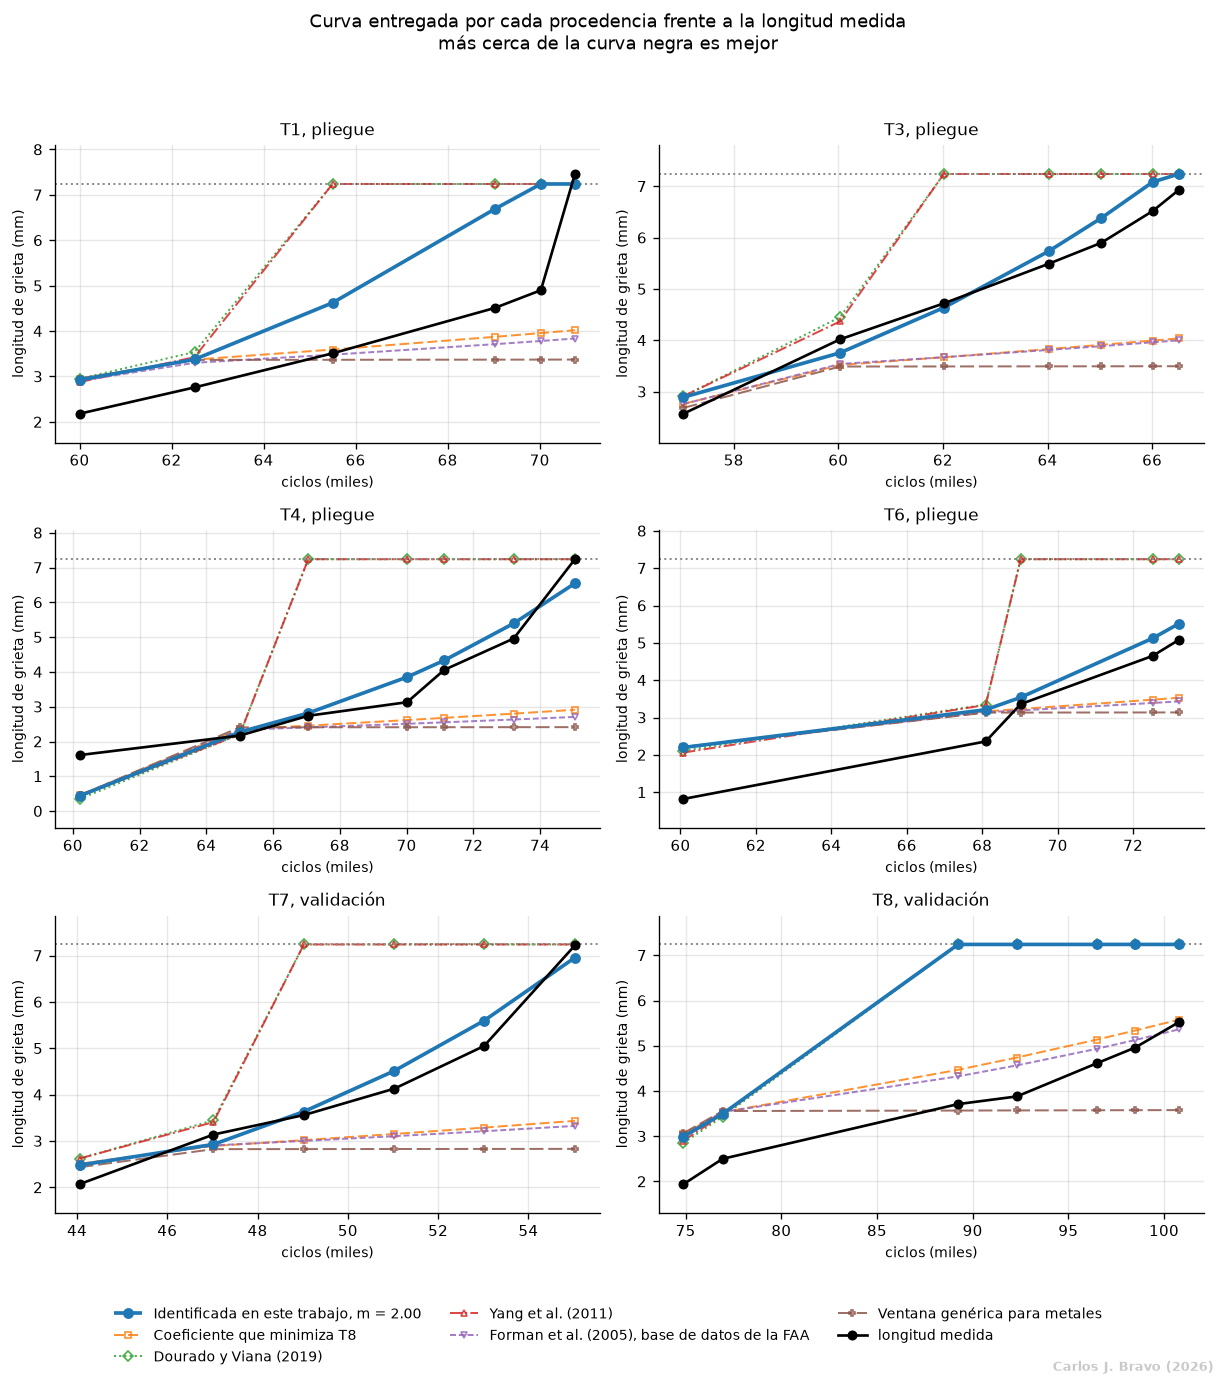

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(10.2, 11.4))
for ax, e in zip(axes.ravel(), ESPECIMENES):
    ref = detalle[ADOPTADA][e]
    ciclos = np.asarray(ref["ciclos"]) / 1e3
    for k, nombre in enumerate(PROCEDENCIAS):
        propia = nombre.startswith("Identificada")
        ax.plot(ciclos, detalle[nombre][e]["entregada_mm"], marker=MARCAS[k],
                linestyle=TRAZOS[k], lw=2.2 if propia else 1.2, ms=5.5 if propia else 4,
                color=COLORES[k], alpha=1.0 if propia else .85,
                markerfacecolor="none" if not propia else None,
                label=nombre if e == ESPECIMENES[0] else None, zorder=3 if propia else 2)
    ax.plot(ciclos, ref["medida_mm"], "ko-", ms=5, lw=1.6,
            label="longitud medida" if e == ESPECIMENES[0] else None, zorder=4)
    ax.axhline(COTA, color="0.55", ls=":", lw=1.2)
    ax.set_title(f"{e}, {'pliegue' if e in LOSO_FOLDS else 'validación'}", fontsize=10)
    ax.set_xlabel("ciclos (miles)", fontsize=8.5)
    ax.set_ylabel("longitud de grieta (mm)", fontsize=8.5)
    ax.margins(y=.12)
fig.suptitle("Curva entregada por cada procedencia frente a la longitud medida\n"
             "más cerca de la curva negra es mejor", y=1.0, fontsize=11)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.062), ncol=3, fontsize=8.5, frameon=False)
marca_de_agua(fig)
fig.tight_layout(rect=(0, 0.075, 1, 0.975)); plt.show()

## 6. La procedencia frente a la configuración

El estudio de ablación del trabajo compara cuatro configuraciones que se diferencian en componentes
de la arquitectura y del motor de extrapolación. Este apartado sitúa el recorrido que produce esa
elección junto al que produce la procedencia de los parámetros físicos, sobre las mismas dos
probetas de validación y con el mismo protocolo.

In [8]:
tabla_cfg = pd.DataFrame([{"variación": etq, "T7": round(v["T7"], 2), "T8": round(v["T8"], 2),
                           "total": round(v["T7"] + v["T8"], 2)}
                          for etq, v in arquitecturas.items()])
display(tabla_cfg)

totales = {n: detalle[n]["T7"]["penalizacion"] + detalle[n]["T8"]["penalizacion"]
           for n in PROCEDENCIAS if not n.startswith("Coeficiente")}
rec_proc = max(totales.values()) - min(totales.values())
rec_cfg = float(tabla_cfg["total"].max() - tabla_cfg["total"].min())
print(f"Recorrido del total de T7 y T8 al cambiar de procedencia   : {rec_proc:8.2f}")
print(f"Recorrido del total de T7 y T8 al cambiar de configuración : {rec_cfg:8.2f}")
print(f"La procedencia mueve el resultado {rec_proc / max(rec_cfg, 1e-9):.0f} veces más.")

,variación,T7,T8,total
0,"Configuraciones 1, 2 y 2b",6.49,90.45,96.94
1,"Configuraciones 3, 4 y 4b",5.88,91.12,97.00


Recorrido del total de T7 y T8 al cambiar de procedencia   :   303.89
Recorrido del total de T7 y T8 al cambiar de configuración :     0.06
La procedencia mueve el resultado 5065 veces más.


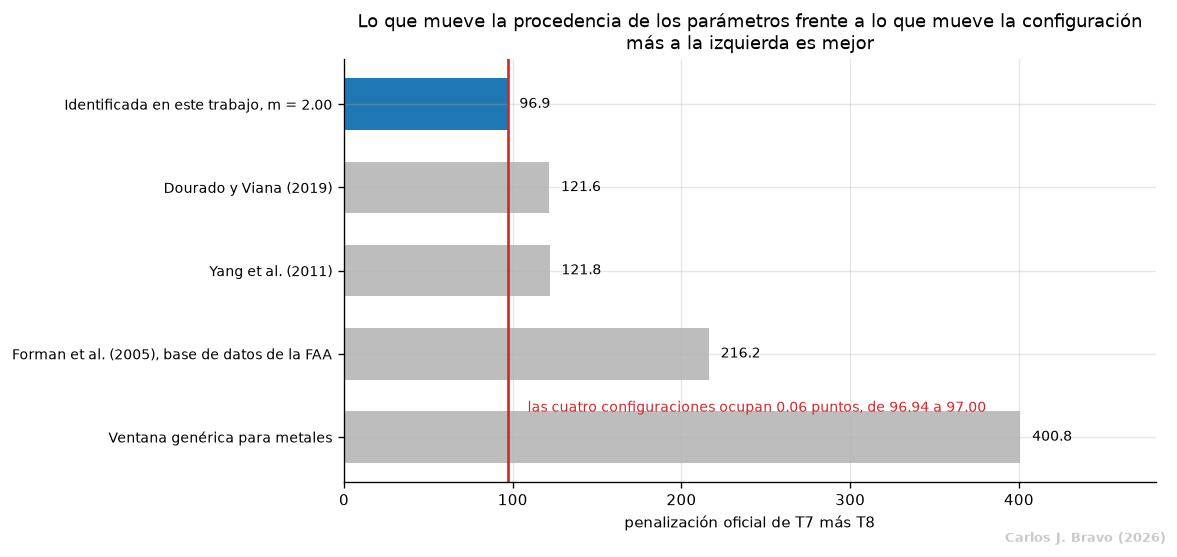

In [9]:
fig, ax = plt.subplots(figsize=(9.8, 4.6))
orden = sorted(totales, key=totales.get, reverse=True)
y = np.arange(len(orden))
ax.barh(y, [totales[n] for n in orden], height=.62,
        color=["C0" if n.startswith("Identificada") else "0.74" for n in orden])
for k, n in enumerate(orden):
    ax.text(totales[n] + 7, k, f"{totales[n]:.1f}", va="center", fontsize=8.5)
ax.set_yticks(y); ax.set_yticklabels(orden, fontsize=8.5)
lo, hi = float(tabla_cfg["total"].min()), float(tabla_cfg["total"].max())
ax.axvline(lo, color="C3", lw=1.6)
ax.annotate(f"las cuatro configuraciones ocupan {hi - lo:.2f} puntos, de {lo:.2f} a {hi:.2f}",
            xy=(lo, 0.35), xytext=(12, 0), textcoords="offset points",
            fontsize=8.5, color="C3", va="center")
ax.set(xlabel="penalización oficial de T7 más T8", xlim=(0, max(totales.values()) * 1.2),
       title="Lo que mueve la procedencia de los parámetros frente a lo que mueve la configuración\n"
             "más a la izquierda es mejor")
marca_de_agua(fig)
fig.tight_layout(); plt.show()

## 7. Frente a las referencias del certamen

Los apartados anteriores contrastan procedencias y arquitecturas entre sí. Éste cambia el término de
comparación y lo lleva fuera del trabajo: las tres reimplementaciones de los métodos premiados,
evaluadas bajo este mismo protocolo. Se comparan las curvas entregadas y no las penalizaciones,
porque es la curva la que muestra en qué tramo se produce el desacuerdo.

El dibujo recorre todos los ciclos puntuados y marca al fondo las tres franjas del protocolo: la de
grieta todavía no detectable ópticamente, la que conserva señal ultrasónica y la ventana ciega que hay
que predecir. Se contrastan las tres procedencias que existen para cada método premiado, lo que
publica su artículo y lo que alcanza su réplica, junto a la Configuración 1. De esta última se
distinguen la entrega, que arranca en el primer anclaje, y la lectura de su estimador, disponible en
todos los ciclos con onda, que es lo que permite ver su comportamiento en la primera franja.

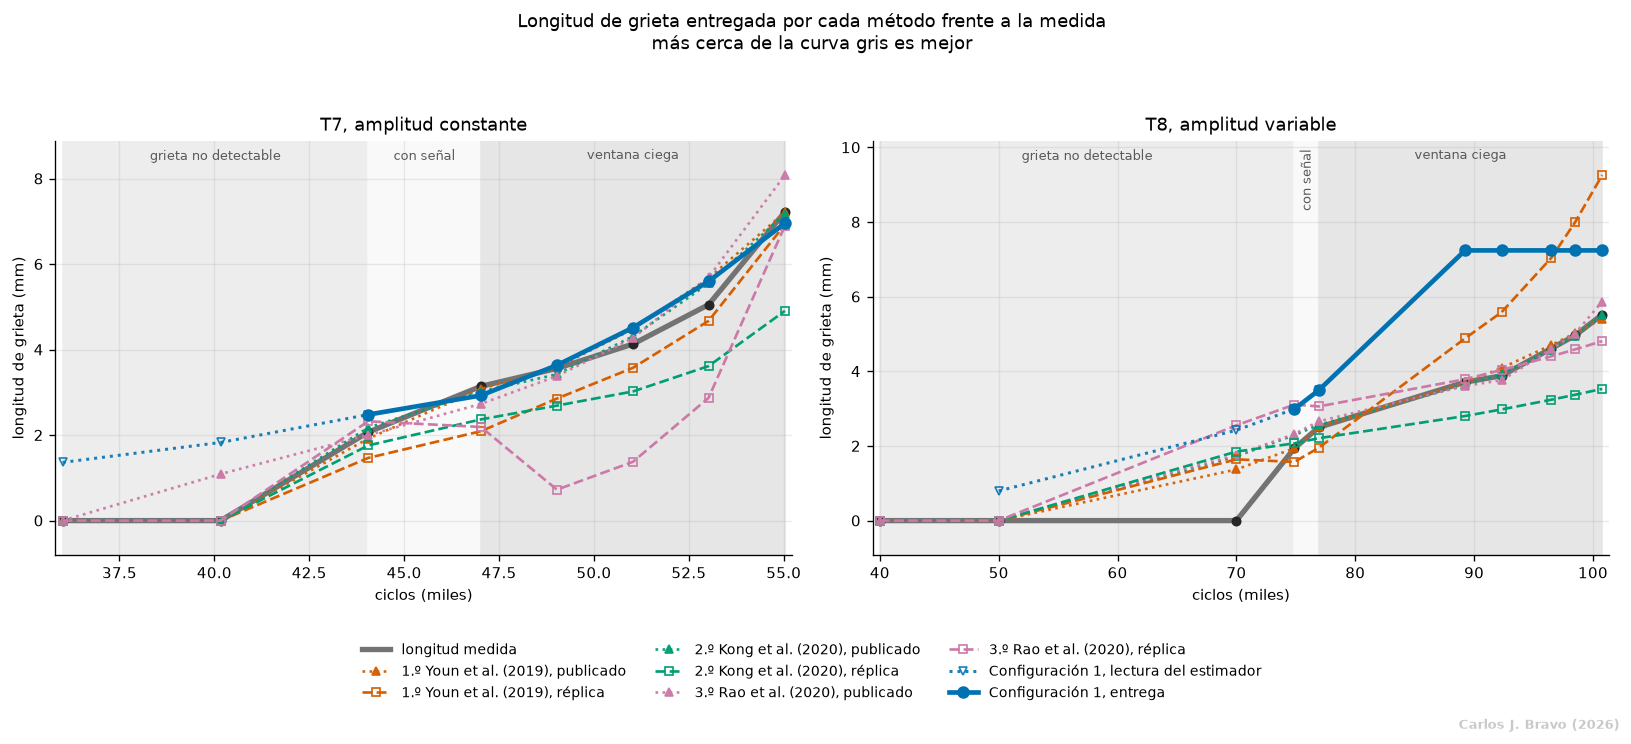

In [10]:
from comparativo_parametros.curvas_referencia import curvas_publicadas, curvas_replicas

publicadas = curvas_publicadas()
replicas = curvas_replicas()
propia = detalle[ADOPTADA]

COLOR_PUESTO = {"1.º Youn et al. (2019)": "#D55E00",
                "2.º Kong et al. (2020)": "#009E73",
                "3.º Rao et al. (2020)": "#CC79A7"}
AZUL = "#0072B2"

fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.0))
for ax, e in zip(axes, ("T7", "T8")):
    ref = propia[e]
    curva = load_curve(e)
    primera = float(curva.cycles[0])
    corte = float(ref["ciclos"][ANCLAS - 1])

    ciclos_med = np.concatenate([np.asarray(curva.zero_cycles, float),
                                 np.asarray(curva.cycles, float)]) / 1e3
    valores_med = np.concatenate([np.zeros(len(curva.zero_cycles)),
                                  np.asarray(curva.crack_mm, float)])

    izq, der = ciclos_med.min(), ciclos_med.max()
    FRANJAS = ((izq, primera / 1e3, "0.93", "grieta no detectable"),
               (primera / 1e3, corte / 1e3, "0.975", "con señal"),
               (corte / 1e3, der, "0.90", "ventana ciega"))
    ancho_total = der - izq
    for a, b, tono, rotulo in FRANJAS:
        ax.axvspan(a, b, color=tono, zorder=0)
        estrecha = (b - a) / ancho_total < 0.13
        ax.annotate(rotulo, xy=((a + b) / 2, 1.0), xycoords=("data", "axes fraction"),
                    xytext=(0, -5), textcoords="offset points", fontsize=7.5,
                    color="0.35", va="top", ha="center",
                    rotation=90 if estrecha else 0)

    ax.plot(ciclos_med, valores_med, "-", color="0.45", lw=3.2,
            label="longitud medida" if e == "T7" else None, zorder=2)
    ax.plot(ciclos_med, valores_med, "o", color="0.15", ms=5, zorder=2)

    for puesto, color in COLOR_PUESTO.items():
        x, y = publicadas[puesto][e]
        ax.plot(x / 1e3, y, "^:", color=color, ms=5, lw=1.6, alpha=.95,
                label=f"{puesto}, publicado" if e == "T7" else None, zorder=3)
        x, y = replicas[puesto][e]
        ax.plot(x / 1e3, y, "s--", color=color, ms=4.5, lw=1.6,
                markerfacecolor="none",
                label=f"{puesto}, réplica" if e == "T7" else None, zorder=4)

    ax.plot(np.asarray(ref["ciclos_obs"], float) / 1e3, ref["estimado_obs"], ":",
            color=AZUL, lw=1.8, marker="v", ms=5, markerfacecolor="none", alpha=.9,
            label="Configuración 1, lectura del estimador" if e == "T7" else None,
            zorder=5)
    ax.plot(np.asarray(ref["ciclos"], float) / 1e3, ref["entregada_mm"], "o-",
            color=AZUL, ms=6.5, lw=2.8,
            label="Configuración 1, entrega" if e == "T7" else None, zorder=6)

    ax.set(xlabel="ciclos (miles)", ylabel="longitud de grieta (mm)",
           title=f"{e}, {'amplitud constante' if e == 'T7' else 'amplitud variable'}")
    ax.grid(alpha=.25)
    ax.margins(x=.01, y=.10)

fig.suptitle("Longitud de grieta entregada por cada método frente a la medida\n"
             "más cerca de la curva gris es mejor", y=1.005, fontsize=11)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center",
           bbox_to_anchor=(0.5, 0.145), ncol=3, fontsize=8.5, frameon=False)
marca_de_agua(fig)
fig.tight_layout(rect=(0, 0.16, 1, 0.965)); plt.show()

### 7.1 El tramo anterior al primer anclaje

Los ciclos que quedan fuera del dibujo no quedan fuera de la puntuación: el certamen puntúa dos de
ellos en T7 y tres en T8, con grieta medida nula. La Configuración 1 no emite entrega ahí, porque su
cauce descarta las medidas nulas, pero su estimador sí los lee. La tabla recoge esa lectura y lo que
habría costado entregarla.

In [11]:
filas = []
for e in ("T7", "T8"):
    ref, curva = propia[e], load_curve(e)
    nulos = set(int(c) for c in curva.zero_cycles)
    for c, v in zip(ref["ciclos_obs"], ref["estimado_obs"]):
        if int(c) in nulos:
            filas.append({"espécimen": e, "ciclo": int(c), "grieta medida (mm)": 0.0,
                          "lectura del estimador (mm)": round(v, 3),
                          "penalización si se entregase": round(float(phm_penalty(
                              np.array([[v]]), np.array([0.0]), curva.final_crack_mm)[0]), 3),
                          "cota superior (mm)": round(float(curva.crack_mm[0]), 2)})
display(pd.DataFrame(filas))

,espécimen,ciclo,grieta medida (mm),lectura del estimador (mm),penalización si se entregase,cota superior (mm)
0,T7,36001,0.0,1.362,0.916,2.07
1,T7,40167,0.0,1.828,1.319,2.07
2,T8,50000,0.0,0.794,0.667,1.94
3,T8,70000,0.0,2.422,2.810,1.94


La última columna es la primera medida positiva del espécimen, que por monotonía acota por arriba la
grieta en esos ciclos. Un cero registrado no significa que no haya grieta, sino que todavía no era
detectable ópticamente, y de hecho la primera medida positiva va de 0.82 mm a 3.25 mm según el
espécimen. Tres de las cuatro lecturas caen por debajo de esa cota y son por tanto compatibles con lo
medido; la excepción es T8 en el ciclo 70 000, que la supera.

Las réplicas se separan de la medida de maneras distintas y ninguna la sigue: la del tercer puesto se
hunde en mitad de T7, la del segundo se queda corta en los dos especímenes y la del primero diverge
en T8. La Configuración 1 es la curva que más se aproxima a la medida en T7 a lo largo de toda la
vida del espécimen; en T8 alcanza la cota de dominio antes del primer ciclo sin señal y entrega un
valor constante, de modo que sobrestima sin divergir.

Sobre el tramo anterior al primer anclaje, la tabla responde a la pregunta que el dibujo plantea. El
estimador lee valores pequeños donde la grieta todavía no es detectable ópticamente, y la última
columna indica lo que costarían si se entregasen, que es la penalización oficial de esos puntos
frente a una medida nula. Ni se dispara ni subestima de forma peligrosa, porque la métrica solo
castiga con dureza la subestimación y ahí no hay nada que subestimar.

## 8. Los pesos entrenados

Los conjuntos que este cuaderno necesita quedan archivados en `models/`, uno por procedencia y
pliegue, de modo que una ejecución posterior los carga en lugar de repetir el entrenamiento. Es lo
que separa los treinta y tres minutos de la primera pasada de los segundos de las siguientes.

In [12]:
print(inventario())

32 conjuntos en models/
  comparativo/arquitectura_media      5 modelos  cnn_pinn                 81 s    0.3 MB
  comparativo/arquitectura_ponderado  5 modelos  cnn_attention_pinn      120 s    0.5 MB
  comparativo/dourado_certamen        5 modelos  cnn_pinn                 82 s    0.3 MB
  comparativo/dourado_sin_T1          3 modelos  cnn_pinn                 42 s    0.2 MB
  comparativo/dourado_sin_T3          3 modelos  cnn_pinn                 41 s    0.2 MB
  comparativo/dourado_sin_T4          3 modelos  cnn_pinn                 40 s    0.2 MB
  comparativo/dourado_sin_T6          3 modelos  cnn_pinn                 42 s    0.2 MB
  comparativo/forman_certamen         5 modelos  cnn_pinn                 84 s    0.3 MB
  comparativo/forman_sin_T1           3 modelos  cnn_pinn                 42 s    0.2 MB
  comparativo/forman_sin_T3           3 modelos  cnn_pinn                 41 s    0.2 MB
  comparativo/forman_sin_T4           3 modelos  cnn_pinn                 42 s    0.2 

## 9. Conclusiones

1. **La procedencia de los parámetros físicos mueve el resultado mucho más que la configuración.**
   Sobre las mismas dos probetas y con el mismo protocolo, cambiar de dónde salen el exponente y el
   coeficiente recorre varios cientos de puntos de penalización, mientras que cambiar de
   configuración recorre centésimas de punto.
2. **La identificación propia es la única procedencia que se comporta bien en todos los
   especímenes.** Las de la literatura ganan como mucho en uno y se degradan en el resto, de modo
   que su ventaja aislada no es un argumento para adoptarlas.
3. **T2 y T5 no admiten evaluación bajo este protocolo**, porque sus dos únicas medidas de grieta no
   nula se consumen como anclas y no dejan ningún punto por predecir. La comparación se establece
   por tanto sobre seis especímenes.
4. **El coeficiente que minimiza T8 no es alcanzable ni deseable fuera de T8.** Se obtiene mirando
   la curva que después puntúa, y aplicado al resto de especímenes multiplica su penalización. La
   corrección que T8 necesita es específica de T8, y ése es el motivo de fondo por el que las
   Configuraciones 2 y 3 no pueden alcanzarla.